In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import fsolve

# Zadanie 1

Przedstaw każde z poniższych równań różniczkowych zwyczajnych jako równoważny układ równań pierwszego rzędu (ang. first-order system of ODEs ):

(a) równanie Van der Pol'a:

$ y'' = y'(1 - y^2) - y $.

(b) równanie Blasiusa:

$ y''' = -y y'' $

(c) II zasada dynamiki Newtona dla problemu dwóch ciał:

$$ y_1'' = -GM y_1 / (y_1^2 + y_2^2)^{3/2} \tag{1} $$
$$ y_2'' = -GM y_2 / (y_1^2 + y_2^2)^{3/2} \tag{2} $$

### Rozwiązanie

(a) równanie Van der Pol'a:
$$
\begin{cases}
y_1 = y' \\ 
y_1' = y_1(1-y^2) - y
\end{cases}
$$

(b) równanie Blasiusa:
$$
\begin{cases}
y_1 = y \\
y_2 = y_1' \\
y_3' = - y_1 y_2'
\end{cases}
$$

(c) II zasada dynamiki Newtona dla problemu dwóch ciał:
$$
\begin{cases}
y_3 = y_1' \\
y_4 = y_2' \\
y_3' = - G M y_1 / (y_1^2 + y_2^2)^{3/2} \\
y_4' = - G M y_2 / (y_1^2 + y_2^2)^{3/2}
\end{cases}
$$

# Zadanie 2

Dane jest równanie różniczkowe zwyczajne

$$ y' = -5y $$

z warunkiem początkowym $y(0) = 1$. Równanie rozwiązujemy numerycznie z krokiem $h = 0.5$.

### Rozwiązanie

Metoda separacji zmiennych
$$ \frac{dy}{y} = -5 dt $$

Całkujemy obie strony
$$ \int \frac{dy}{y} = \int -5 dt $$
$$ \ln|y| = -5t + C $$

Rozwiązujemy równanie dla $y$
$$ y = e^{-5t + C} = e^C e^{-5t} = C' e^{-5t} $$

Podstawiamy warunek początkowy
$$ y(0) = C' = 1 $$

Ostateczne rozwiązanie
$$ y(t) = e^{-5t} $$

(a) Analityczna stabilność. Wyjaśnij, czy rozwiązania powyższego równania są stabilne?

### Rozwiązanie

Rozwiązanie $ y(t) = e^{-5t} $ jest stabilne, jeśli dla dowolnego $ \varepsilon $ istnieje $ \delta $ takie, że
$$ || \hat{y}(0) - y(0) || < \delta \Rightarrow || \hat{y}(t) - y(t) || < \varepsilon \text{ dla } t \ge 0 $$

$$ | C' - 1 | < \delta \Rightarrow | C' e^{-5t} - e^{-5t} | < \varepsilon $$

Ponieważ
$$ | C' e^{-5t} - e^{-5t} | = | e^{-5t} | \cdot | C' - 1 | \le 1 \cdot | C' - 1 | \le | C' - 1 | $$
to dla $ \delta = \varepsilon $ implikacja jest prawdziwa, a więc rozwiązanie jest stabilne.

Ponieważ
$$ \lim_{t \to \infty} || \hat{y}(t) - y(t) || = \lim_{t \to \infty} | C' e^{-5t} - e^{-5t} | = \lim_{t \to \infty} | e^{-5t} | \cdot | C' - 1 | = 0 $$
to rozwiązanie jest także asymptotycznie stabilne.

(b) Numeryczna stabilność. Wyjaśnij, czy metoda Euler’a jest stabilna dla tego równania z użytym krokiem $h$?

### Rozwiązanie

Metoda Eulera dla równania $ y' = -5y $ z krokiem $h$ ma postać
$$ y_{k+1} = y_k + h (-5 y_k) = y_k (1 - 5h) $$

Dla stabilności numerycznej metoda Eulera musi spełniać warunek
$$ |1 - 5h| \le 1 $$

Po przekształceniu otrzymujemy
$$ -1 \le 1 - 5h \le 1 $$
$$ -2 \le -5h \le 0 $$
$$ 0 \le h \le \frac{2}{5} = 0.4 $$

Ponieważ $ h = 0.5 > 0.4 $, to metoda Eulera jest niestabilna dla tego równania z użytym krokiem $h$.

(c) Oblicz numerycznie wartości przybliżonego rozwiązania dla $t = 0.5$ metodą Euler’a.

In [2]:
def euler_method(f, y0, t0, t_end, h):
    """
    Implementacja metody Eulera do numerycznego rozwiązywania równań różniczkowych.

    f : funkcja
        Funkcja określająca równanie różniczkowe y' = f(t, y).
    y0 : float
        Początkowa wartość y w czasie t0.
    t0 : float
        Początkowy czas.
    t_end : float
        Końcowy czas.
    h : float
        Krok czasowy.

    Zwraca:
    t_values : numpy array
        Tablica wartości czasowych.
    y_values : numpy array
        Tablica wartości y odpowiadających każdemu czasowi z t_values.
    """
    # Inicjalizacja zmiennych
    t_values = np.arange(t0, t_end + h, h)
    y_values = np.zeros(len(t_values))

    # Warunek początkowy
    y_values[0] = y0

    # Iteracja metodą Eulera
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]
        y_values[i] = y + h * f(t, y)

    return t_values, y_values

In [3]:
def dydt(t, y):
    return -5 * y


# Warunek początkowy i parametry
y0 = 1
t0 = 0
t_end = 0.5
h = 0.5

# Rozwiązanie równania metodą Eulera
t_values, y_values = euler_method(dydt, y0, t0, t_end, h)


print("Metoda Eulera:")
for t, y in zip(t_values, y_values):
    print(f"t = {t:.2f}, y = {y:.5f}")

Metoda Eulera:
t = 0.00, y = 1.00000
t = 0.50, y = -1.50000


(d) Wyjaśnij, czy niejawna metoda Euler’a jest stabilna dla tego równania z użytym krokiem $h$?

### Rozwiązanie

Niejawna metoda Eulera dla równania $ y' = -5y $ z krokiem $h$ ma postać
$$ y_{k+1} = y_k + h (-5 y_{k+1}) $$

Po przekształceniu otrzymujemy
$$ y_{k+1} = \frac{y_k}{1 + 5h} $$

Dla stabilności numerycznej niejawna metoda Eulera musi spełniać warunek
$$ \left| \frac{1}{1 + 5h} \right| \le 1 $$
co jest spełnione dla dowolnego $h > 0$, a więc niejawna metoda Eulera jest stabilna dla tego równania z użytym krokiem $h = 0.5$.

(e) Oblicz numerycznie wartości przybliżonego rozwiązania dla $t = 0.5$ niejawną metodą Euler'a.

In [4]:
def implicit_euler_method(f, y0, t0, t_end, h):
    """
    Implementacja niejawną metodą Eulera do numerycznego rozwiązywania równań różniczkowych.

    f : funkcja
        Funkcja określająca równanie różniczkowe y' = f(t, y).
    y0 : float
        Początkowa wartość y w czasie t0.
    t0 : float
        Początkowy czas.
    t_end : float
        Końcowy czas.
    h : float
        Krok czasowy.

    Zwraca:
    t_values : numpy array
        Tablica wartości czasowych.
    y_values : numpy array
        Tablica wartości y odpowiadających każdemu czasowi z t_values.
    """
    t_values = np.arange(t0, t_end + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = y0

    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y_prev = y_values[i - 1]

        # Definicja równania nieliniowego do rozwiązania
        def implicit_eq(y_next):
            return y_next - y_prev - h * f(t + h, y_next)

        # Użycie metody Newtona-Raphsona (fsolve) do rozwiązania równania nieliniowego
        y_next = fsolve(implicit_eq, y_prev)[0]
        y_values[i] = y_next

    return t_values, y_values

In [5]:
def dydt(t, y):
    return -5 * y


# Warunek początkowy i parametry
y0 = 1
t0 = 0
t_end = 0.5
h = 0.5

# Rozwiązanie równania metodą Eulera
t_values, y_values = implicit_euler_method(dydt, y0, t0, t_end, h)


print("Niejawna Metoda Eulera:")
for t, y in zip(t_values, y_values):
    print(f"t = {t:.2f}, y = {y:.5f}")

Niejawna Metoda Eulera:
t = 0.00, y = 1.00000
t = 0.50, y = 0.28571


# Zadanie 3

Model Kermack’a-McKendrick’a przebiegu epidemii w populacji opisany jest układem równań różniczkowych:

$$ S' = -\frac{\beta}{N} I S , \tag{3} $$

$$ I' = \frac{\beta}{N} I S - \gamma I , \tag{4} $$

$$ R' = \gamma I , \tag{5} $$

gdzie
- $S$ reprezentuje liczbę osób zdrowych, podatnych na zainfekowanie,
- $I$ reprezentuje liczbę osób zainfekowanych i roznoszących infekcję,
- $R$ reprezentuje liczbę osób ozdrowiałych.

Liczba $N$ to liczba osób w populacji. Parametr $\beta$ reprezentuje współczynnik zakaźności (ang. transmission rate). Parametr $\gamma$ reprezentuje współczynnik wyzdrowień (ang. recovery rate). Wartość $1/\gamma$ reprezentuje średni czas choroby.

Założenia modelu:
- Przyrost liczby osób zakażonych jest proporcjonalny do liczby osób zakażonych oraz do liczby osób podatnych.
- Przyrost liczby osób odppornych lub zmarłych jest wprost proporcjonalny do liczby aktualnie chorych.
- Okres inkubacji choroby jest zaniedbywalnie krótki.
- Populacja jest wymieszana.

$$ [\text{Susceptible}] \xrightarrow{\beta I S} [\text{Infectious}] \xrightarrow{\gamma I} [\text{Recovered}]$$

Jako wartości początkowe ustal:

$$ S(0) = 762, \ I(0) = 1, \ R(0) = 0 \text{.} $$

Przyjmij też $N = S(0)+I(0)+R(0) = 763$ oraz $\beta = 1$. Zakładając, że średni czas trwania grypy wynosi $1/\gamma = 7 \text{dni}$, przyjmij $\gamma = 1/7$.

Całkując od $t = 0$ do $t = 14$ z krokiem $0.2$, rozwiąż powyższy układ równań:

In [6]:
# Definicje równań różniczkowych
def SIR_model(S, I, R, beta, gamma, N):
    dS = -beta * S * I / N
    dI = beta * S * I / N - gamma * I
    dR = gamma * I
    return dS, dI, dR


# Parametry modelu
beta = 1.0
gamma = 1 / 7
N = 763
S0, I0, R0 = 762, 1, 0

# Czas symulacji
t = np.arange(0, 14.2, 0.2)
h = 0.2

- jawną metodą Eulera
$$ y_{k+1} = y_k + h_k f(t_k, y_k) $$

In [7]:
def solve_SIR_explicit_euler(beta, gamma, t, S0, I0, R0, N):
    S, I, R = [S0], [I0], [R0]
    h = t[1] - t[0]

    for _ in t[:-1]:
        dS, dI, dR = SIR_model(S[-1], I[-1], R[-1], beta, gamma, N)
        S.append(S[-1] + h * dS)
        I.append(I[-1] + h * dI)
        R.append(R[-1] + h * dR)

    return np.array(S), np.array(I), np.array(R)

- niejawną metodą Eulera
$$ y_{k+1} = y_k + h_k f(t_{k+1}, y_{k+1}) $$

In [8]:
def solve_SIR_implicit_euler(beta, gamma, t, S0, I0, R0, N):
    S, I, R = [S0], [I0], [R0]
    h = t[1] - t[0]

    def equations(vars, S_prev, I_prev, R_prev):
        S_new, I_new, R_new = vars
        f1 = S_new - S_prev - h * (-beta * S_new * I_new / N)
        f2 = I_new - I_prev - h * (beta * S_new * I_new / N - gamma * I_new)
        f3 = R_new - R_prev - h * (gamma * I_new)
        return [f1, f2, f3]

    for _ in t[1:]:
        S_prev, I_prev, R_prev = S[-1], I[-1], R[-1]
        S_new, I_new, R_new = fsolve(equations, (S_prev, I_prev, R_prev), args=(S_prev, I_prev, R_prev))
        S.append(S_new)
        I.append(I_new)
        R.append(R_new)

    return np.array(S), np.array(I), np.array(R)

- metodą Rungego-Kutty czwartego rzędu (RK4)
$$ y_{k+1} = y_k + \frac{h_k}{6}(k_1 + 2k_2 + 2k_3 + k4) \text{, gdzie} $$
$$ k_1 = f(t_k, y_k) $$
$$ k_2 = f(t_k + h_k / 2, y_k + h_k k_1 / 2) $$
$$ k_3 = f(t_k + h_k / 2, y_k + h_k k_2 / 2) $$
$$ k_4 = f(t_k + h_k, y_k + k_k k_3) $$

In [9]:
def solve_SIR_RK4(beta, gamma, t, S0, I0, R0, N):
    S, I, R = [S0], [I0], [R0]
    h = t[1] - t[0]

    for _ in t[:-1]:
        S_current, I_current, R_current = S[-1], I[-1], R[-1]
        dS1, dI1, dR1 = SIR_model(S_current, I_current, R_current, beta, gamma, N)

        S1, I1, R1 = (
            S_current + h * dS1 / 2,
            I_current + h * dI1 / 2,
            R_current + h * dR1 / 2,
        )
        dS2, dI2, dR2 = SIR_model(S1, I1, R1, beta, gamma, N)

        S2, I2, R2 = (
            S_current + h * dS2 / 2,
            I_current + h * dI2 / 2,
            R_current + h * dR2 / 2,
        )
        dS3, dI3, dR3 = SIR_model(S2, I2, R2, beta, gamma, N)

        S3, I3, R3 = (
            S_current + h * dS3,
            I_current + h * dI3,
            R_current + h * dR3,
        )
        dS4, dI4, dR4 = SIR_model(S3, I3, R3, beta, gamma, N)

        S_next = S_current + h * (dS1 + 2 * dS2 + 2 * dS3 + dS4) / 6
        I_next = I_current + h * (dI1 + 2 * dI2 + 2 * dI3 + dI4) / 6
        R_next = R_current + h * (dR1 + 2 * dR2 + 2 * dR3 + dR4) / 6

        S.append(S_next)
        I.append(I_next)
        R.append(R_next)

    return np.array(S), np.array(I), np.array(R)

Wykonaj nastepujące wykresy:
- Dla każdej metody przedstaw na wspólnym rysunku wykresy komponentów rozwiązania ($S$, $I$, $R$) jako funkcje $t$ (3 wykresy).

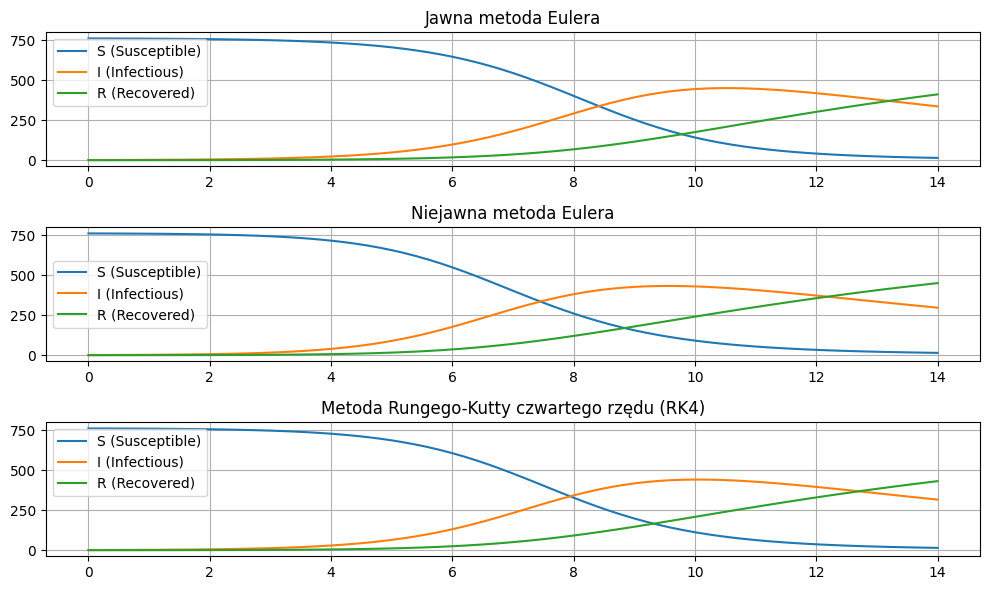

In [10]:
plt.figure(figsize=(10, 6))

# Jawna metoda Eulera
S_E, I_E, R_E = solve_SIR_explicit_euler(beta, gamma, t, S0, I0, R0, N)
plt.subplot(3, 1, 1)
plt.plot(t, S_E, label="S (Susceptible)")
plt.plot(t, I_E, label="I (Infectious)")
plt.plot(t, R_E, label="R (Recovered)")
plt.title("Jawna metoda Eulera")
plt.legend()
plt.grid()

# Niejawna metoda Eulera
S_IE, I_IE, R_IE = solve_SIR_implicit_euler(beta, gamma, t, S0, I0, R0, N)
plt.subplot(3, 1, 2)
plt.plot(t, S_IE, label="S (Susceptible)")
plt.plot(t, I_IE, label="I (Infectious)")
plt.plot(t, R_IE, label="R (Recovered)")
plt.title("Niejawna metoda Eulera")
plt.legend()
plt.grid()

# Metoda RK4
S_RK, I_RK, R_RK = solve_SIR_RK4(beta, gamma, t, S0, I0, R0, N)
plt.subplot(3, 1, 3)
plt.plot(t, S_RK, label="S (Susceptible)")
plt.plot(t, I_RK, label="I (Infectious)")
plt.plot(t, R_RK, label="R (Recovered)")
plt.title("Metoda Rungego-Kutty czwartego rzędu (RK4)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

- Na wspólnym rysunku przedstaw wykresy funkcji $S(t)+I(t)+R(t)$ znalezione przez każdą metodę (1 wykres). Czy niezmiennik $S(t)+I(t)+R(t) \equiv N$ jest zachowany?

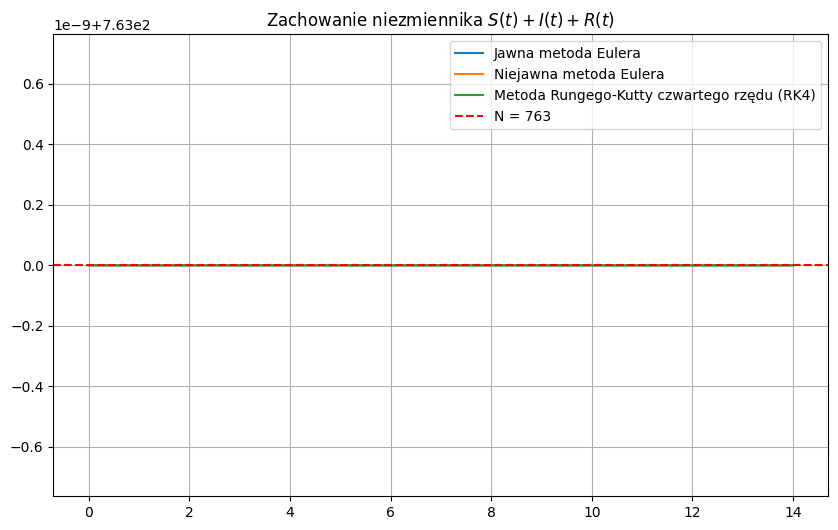

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(t, S_E + I_E + R_E, label="Jawna metoda Eulera")
plt.plot(t, S_IE + I_IE + R_IE, label="Niejawna metoda Eulera")
plt.plot(t, S_RK + I_RK + R_RK, label="Metoda Rungego-Kutty czwartego rzędu (RK4)")
plt.axhline(y=N, color="r", linestyle="--", label="N = 763")
plt.title("Zachowanie niezmiennika $S(t) + I(t) + R(t)$")
plt.legend()
plt.grid()
plt.show()

Wiemy, że liczba osób zakażonych w pewnej szkole kształtowała się następująco:
$$
\begin{matrix}
\text{Dzień, } t & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 & 12 & 13 & 14 \\
\text{Zakażeni, } I & 1 & 3 & 6 & 25 & 73 & 222 & 294 & 258 & 237 & 191 & 125 & 69 & 27 & 11 & 4 
\end{matrix}
$$

In [12]:
# Dane rzeczywiste
I_true = np.array([1, 3, 6, 25, 73, 222, 294, 258, 237, 191, 125, 69, 27, 11, 4])
t_real = np.arange(15)

Wybierz jedną z powyższych metod numerycznych i oszacuj prawdziwe wartości współczynników $\theta = [\beta,\gamma]$. W tym celu wykonaj minimalizację funkcji kosztu. Jako funkcję kosztu wykorzystaj sumę kwadratów reszt (ang. residualsum of squares):

$$ L(\theta) = \sum_{i=0}^{T}{(I_i - \hat{I_i})^2} \text{, }$$

gdzie $I_i$ oznacza prawdziwą liczbę zakażonych, a $\hat{I_i}$ oznacza liczbę zakażonych wyznaczonych metodą numeryczną. Ponieważ nie znamy gradientu $\nabla_\theta L(\theta)$, do minimalizacji wykorzystaj metodę Neldera-Meada, która nie wymaga informacji o gradiencie.

In [13]:
def cost_function_RSS(params, I_true, t, S0, I0, R0, N):
    beta, gamma = params
    _, I_pred, _ = solve_SIR_RK4(beta, gamma, t, S0, I0, R0, N)
    RSS = np.sum((I_true - I_pred) ** 2)
    return RSS

Powtórz obliczenia, tym razem jako funkcję kosztu wykorzystując:

$$ L(\theta) = - \sum_{i=0}^{T}{I_i \ln{\hat{I_i}}} + \sum_{i=0}^{T}{\hat{I_i}} \text{ .} $$

In [14]:
def cost_function_LN(params, I_true, t, S0, I0, R0, N):
    beta, gamma = params
    _, I_pred, _ = solve_SIR_RK4(beta, gamma, t, S0, I0, R0, N)
    LN = np.sum(-I_true * np.log(I_pred) + I_pred)
    return LN

Ile wynosił współczynnik reprodukcji $R_0 = \beta / \gamma$ w każdym przypadku?

In [15]:
initial_guess = [1.0, 1 / 7]
result_RSS = minimize(
    cost_function_RSS,
    initial_guess,
    args=(I_true, t_real, S0, I0, R0, N),
    method="Nelder-Mead",
)
result_LN = minimize(
    cost_function_LN,
    initial_guess,
    args=(I_true, t_real, S0, I0, R0, N),
    method="Nelder-Mead",
)

# Wyniki
beta_RSS, gamma_RSS = result_RSS.x
beta_LN, gamma_LN = result_LN.x

R0_RSS = beta_RSS / gamma_RSS
R0_LN = beta_LN / gamma_LN

print("Metoda minimalizacji sumy kwadratów reszt (RSS):")
print(f"beta = {beta_RSS:.3f}, gamma = {gamma_RSS:.3f}, R0 = {R0_RSS:.3f}")
print("Metoda minimalizacji drugiej funkcji kosztu:")
print(f"beta = {beta_LN:.3f}, gamma = {gamma_LN:.3f}, R0 = {R0_LN:.3f}")

Metoda minimalizacji sumy kwadratów reszt (RSS):
beta = 1.670, gamma = 0.446, R0 = 3.747
Metoda minimalizacji drugiej funkcji kosztu:
beta = 1.693, gamma = 0.481, R0 = 3.520
